<a href="https://colab.research.google.com/github/Sashanka2001/pre-enhancement--Google-Colab/blob/main/Google_Col_pre_enhancement_facial_recoverability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Cell 1: Environment & Dependency Setup
# Install core dependencies and Python 3.13-compatible builds for rembg & OpenCV
!pip install -q mediapipe pandas matplotlib scikit-image tqdm datasets
!pip install -U --prefer-binary "rembg[cpu]" onnxruntime pillow opencv-python-headless

In [3]:
#Directory Setup & Google Drive Mounting
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Project paths on Google Drive
DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
DIR_ORIGINAL = os.path.join(DRIVE_PROJECT, "dataset/original")
DIR_CROPPED = os.path.join(DRIVE_PROJECT, "dataset/cropped")
DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")
DIR_METADATA = os.path.join(DRIVE_PROJECT, "dataset/metadata")

# 3. List of degradation subfolders
degraded_types = [
    "blur",
    "noise",
    "brightness",
    "contrast",
    "jpeg",
    "low_resolution",
    "combined"
]

# 4. Create local directory structure
local_directories = [
    "dataset/original",
    "dataset/cropped",
    "dataset/metadata",
    "graphs"
] + [f"dataset/degraded/{sub}" for sub in degraded_types]

for folder in local_directories:
    os.makedirs(folder, exist_ok=True)

# 5. Create Google Drive directory structure
drive_directories = [
    DIR_ORIGINAL,
    DIR_CROPPED,
    DIR_METADATA
] + [os.path.join(DIR_DEGRADED, sub) for sub in degraded_types]

for folder in drive_directories:
    os.makedirs(folder, exist_ok=True)

print("Workspace and Google Drive paths (including all degraded subfolders) initialized successfully!")

Mounted at /content/drive
Workspace and Google Drive paths (including all degraded subfolders) initialized successfully!


In [4]:
# Step 1: Download Additional FFHQ Faces Directly to Google Drive (Batch Download)

import cv2
import shutil
import os
from tqdm import tqdm

def download_ffhq_straight_to_drive(output_dir: str = DIR_ORIGINAL,
                                    start_index: int = 101,  # Starting image number
                                    end_index: int = 500):  # Target ending image number

    # Check if Google Drive already contains images up to end_index
    existing_files = [f for f in os.listdir(output_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(existing_files) >= end_index:
        print(f"Google Drive directory '{output_dir}' already contains {len(existing_files)} original faces.")
        print("Skipping download process!")
        return

    !pip install -q kagglehub
    import kagglehub

    print("Downloading high-resolution FFHQ dataset from Kaggle...")
    kaggle_path = kagglehub.dataset_download("arnaud58/flickrfaceshq-dataset-ffhq")

    image_files = []
    for root, _, files in os.walk(kaggle_path):
        for file in sorted(files):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(os.path.join(root, file))

    # Slice the image list to select only the specified batch
    batch_images = image_files[start_index - 1 : end_index]

    print(f"Saving faces {start_index} to {start_index + len(batch_images) - 1} directly to Google Drive...")

    # Save images to Google Drive
    for i, src in enumerate(tqdm(batch_images, desc="Saving to Google Drive")):
        img = cv2.imread(src)
        if img is not None:
            face_number = start_index + i
            dest = os.path.join(output_dir, f"face_{face_number:04d}.png")
            cv2.imwrite(dest, img)

    # Clean temporary writable Kaggle download cache safely without failing on read-only mounts
    if os.path.exists("/root/.cache/kagglehub"):
        shutil.rmtree("/root/.cache/kagglehub", ignore_errors=True) # <-- CHANGED: Ignores read-only errors

    print(f"\nSuccess! Images {start_index} through {start_index + len(batch_images) - 1} saved into Google Drive.")

# Execute batch download
download_ffhq_straight_to_drive(output_dir=DIR_ORIGINAL, start_index=101, end_index=500)

Google Drive directory '/content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/original' already contains 1000 original faces.
Skipping download process!


In [19]:
# Cell 4: Verify Saved FFHQ Images in Drive (Updated for Batch Range & Full Dataset Verification)

import os
import cv2

def verify_drive_images(input_dir: str = DIR_ORIGINAL,
                        start_index: int = 101,   # <-- CHANGED: Start index of the new batch
                        end_index: int = 500):   # <-- CHANGED: End index of the new batch

    # Get all valid image files in Google Drive
    files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    valid_count = 0
    sample_specs = []

    # Generate exact filenames for the targeted batch to extract sample specs
    target_sample_names = [f"face_{i:04d}.png" for i in range(start_index, start_index + 3)] # <-- CHANGED: Target face_0501, face_0502, face_0503

    for filename in files:
        path = os.path.join(input_dir, filename)

        # Check if file exists and is non-empty
        if os.path.getsize(path) > 0: # <-- CHANGED: Fast disk verification check
            valid_count += 1

            # Read image metadata specifically for files in the new batch range
            if filename in target_sample_names: # <-- CHANGED: Samples specifically from newly added batch
                img = cv2.imread(path)
                if img is not None:
                    sample_specs.append((filename, img.shape))

    print(f"Total Valid FFHQ Images Verified in Google Drive: {valid_count}/{len(files)}")
    print(f"\nSample File Specifications for New Batch ({start_index} - {end_index}):") # <-- CHANGED: Updated print label
    for name, shape in sample_specs:
        print(f" - {name}: {shape[1]}x{shape[0]} pixels, {shape[2]} channels (BGR)")

# Execute verification for images 101 through 500
verify_drive_images(input_dir=DIR_ORIGINAL, start_index=101, end_index=500) # <-- CHANGED: Pass active batch range

Total Valid FFHQ Images Verified in Google Drive: 1000/1000

Sample File Specifications for New Batch (101 - 500):
 - face_0101.png: 512x512 pixels, 3 channels (BGR)
 - face_0102.png: 512x512 pixels, 3 channels (BGR)
 - face_0103.png: 512x512 pixels, 3 channels (BGR)


In [6]:
# Step 2: Background Removal & Facial Segmentation (Batch Processing with Auto-Resume)

import os
from PIL import Image
from rembg import remove
from tqdm import tqdm

def segment_faces_directly_to_drive(input_dir: str = DIR_ORIGINAL,
                                    output_dir: str = DIR_CROPPED,
                                    background_color: tuple = (255, 255, 255),
                                    start_index: int = 101,  # <-- CHANGED: Starting image number
                                    end_index: int = 200):   # <-- CHANGED: Target ending image number
    """
    Reads original faces from Google Drive, performs AI background removal,
    and saves cutouts into Google Drive for a specified index range.
    Automatically skips files that already exist.
    """
    os.makedirs(output_dir, exist_ok=True)

    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    all_image_files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to process only the targeted batch (adjusting for 0-based Python indexing)
    batch_image_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices images from start_index to end_index

    processed_count = 0
    skipped_count = 0

    print(f"Processing background removal for faces {start_index} to {start_index + len(batch_image_files) - 1}...")

    for filename in tqdm(batch_image_files, desc="Removing Backgrounds"):
        src_path = os.path.join(input_dir, filename)
        output_filename = os.path.splitext(filename)[0] + ".png"
        dest_path = os.path.join(output_dir, output_filename)

        # Skip files already present in Google Drive
        if os.path.exists(dest_path):
            skipped_count += 1
            continue

        try:
            input_image = Image.open(src_path)
            segmented_image = remove(input_image)

            if background_color is not None:
                canvas = Image.new("RGBA", segmented_image.size, background_color + (255,))
                final_image = Image.alpha_composite(canvas, segmented_image).convert("RGB")
            else:
                final_image = segmented_image

            final_image.save(dest_path)
            processed_count += 1

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    print(f"\nComplete! Processed {processed_count} new images. Skipped {skipped_count} existing images.")

# Execute background removal for images 101 through 200
segment_faces_directly_to_drive(input_dir=DIR_ORIGINAL,
                                output_dir=DIR_CROPPED,
                                background_color=(255, 255, 255),
                                start_index=101,   # <-- CHANGED: Set batch start index
                                end_index=200)     # <-- CHANGED: Set batch end index

Processing background removal for faces 101 to 200...


Removing Backgrounds: 100%|██████████| 100/100 [16:31<00:00,  9.91s/it]


Complete! Processed 15 new images. Skipped 85 existing images.


In [7]:
# Check Background Removal Progress (Cropped vs Original Images)

import os

# Google Drive project paths
DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
DIR_ORIGINAL = os.path.join(DRIVE_PROJECT, "dataset/original")
DIR_CROPPED = os.path.join(DRIVE_PROJECT, "dataset/cropped")

valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

def check_segmentation_progress():
    total_original = len([f for f in os.listdir(DIR_ORIGINAL) if f.lower().endswith(valid_extensions)]) if os.path.exists(DIR_ORIGINAL) else 0
    total_cropped = len([f for f in os.listdir(DIR_CROPPED) if f.lower().endswith(valid_extensions)]) if os.path.exists(DIR_CROPPED) else 0

    percentage = (total_cropped / total_original * 100) if total_original > 0 else 0.0

    print("✂️ BACKGROUND REMOVAL PROGRESS")
    print(f"• Progress Ratio : {total_cropped} / {total_original}")
    print(f"• Completion Rate: {percentage:.1f}%")
    print(f"• Remaining      : {total_original - total_cropped} images")

check_segmentation_progress()

✂️ BACKGROUND REMOVAL PROGRESS
• Progress Ratio : 200 / 1000
• Completion Rate: 20.0%
• Remaining      : 800 images


In [8]:
# Setup & Directory Paths
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")
DIR_METADATA = os.path.join(DRIVE_PROJECT, "dataset/metadata")

In [22]:
# Degradation 1: Gaussian Blur

import os
import cv2
from tqdm import tqdm

def generate_blur_degradations(cropped_dir: str = DIR_CROPPED,
                               output_dir: str = os.path.join(DIR_DEGRADED, "blur"),
                               start_index: int = 101,  # <-- CHANGED: Starting image number
                               end_index: int = 200):   # <-- CHANGED: Ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    records = []
    print(f"Applying Gaussian Blur to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="1/7 Applying Gaussian Blur"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for sig in [1, 2, 3, 5, 7]:
            deg_filename = f"{base_name}_blur_s{sig}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                kernel_size = 2 * int(3 * sig) + 1
                blurred_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), sig)
                cv2.imwrite(save_path, blurred_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Gaussian Blur",
                "severity_parameter": "sigma",
                "parameter_value": float(sig),
                "drive_path": save_path
            })
    return records

# Execute Gaussian Blur for cutouts 101 through 200
blur_records = generate_blur_degradations(start_index=101, end_index=200)

Applying Gaussian Blur to cutouts 101 through 200...


1/7 Applying Gaussian Blur: 100%|██████████| 100/100 [00:18<00:00,  5.29it/s]


In [23]:
# Degradation 2: Gaussian Noise

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_noise_degradations(cropped_dir: str = DIR_CROPPED,
                                output_dir: str = os.path.join(DIR_DEGRADED, "noise"),
                                start_index: int = 101,  # <-- CHANGED: Starting image number
                                end_index: int = 200):   # <-- CHANGED: Target ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    records = []
    print(f"Applying Gaussian Noise to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="2/7 Applying Gaussian Noise"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for std in [5, 10, 15, 20, 30]:
            deg_filename = f"{base_name}_noise_s{std}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                noise = np.random.normal(0, std, img.shape).astype(np.float32)
                noisy_img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
                cv2.imwrite(save_path, noisy_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Gaussian Noise",
                "severity_parameter": "std_dev",
                "parameter_value": float(std),
                "drive_path": save_path
            })
    return records

# Execute Gaussian Noise for cutouts 101 through 200
noise_records = generate_noise_degradations(start_index=101, end_index=200) # <-- CHANGED: Pass active batch range

Applying Gaussian Noise to cutouts 101 through 200...


2/7 Applying Gaussian Noise: 100%|██████████| 100/100 [00:37<00:00,  2.64it/s]


In [24]:
 # Degradation 3: Brightness Scaling

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_brightness_degradations(cropped_dir: str = DIR_CROPPED,
                                     output_dir: str = os.path.join(DIR_DEGRADED, "brightness"),
                                     start_index: int = 101,  # <-- CHANGED: Starting image number
                                     end_index: int = 200):   # <-- CHANGED: Target ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    records = []
    print(f"Applying Brightness Scaling to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="3/7 Applying Brightness Scaling"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for alpha in [0.6, 0.8, 1.2, 1.4]:
            deg_filename = f"{base_name}_bright_a{alpha}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                bright_img = np.clip(img.astype(np.float32) * alpha, 0, 255).astype(np.uint8)
                cv2.imwrite(save_path, bright_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Brightness",
                "severity_parameter": "alpha",
                "parameter_value": float(alpha),
                "drive_path": save_path
            })
    return records

# Execute Brightness Scaling for cutouts 101 through 200
bright_records = generate_brightness_degradations(start_index=101, end_index=200) # <-- CHANGED: Pass active batch range

Applying Brightness Scaling to cutouts 101 through 200...


3/7 Applying Brightness Scaling: 100%|██████████| 100/100 [00:14<00:00,  6.74it/s]


In [25]:
 # Degradation 4: Contrast Adjustment

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_contrast_degradations(cropped_dir: str = DIR_CROPPED,
                                   output_dir: str = os.path.join(DIR_DEGRADED, "contrast"),
                                   start_index: int = 101,  # <-- CHANGED: Starting image number
                                   end_index: int = 200):   # <-- CHANGED: Target ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    records = []
    print(f"Applying Contrast Adjustment to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="4/7 Applying Contrast Adjustment"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)
        mean_val = np.mean(img)

        for beta in [0.6, 0.8, 1.2, 1.5]:
            deg_filename = f"{base_name}_contrast_b{beta}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                contrast_img = np.clip((img.astype(np.float32) - mean_val) * beta + mean_val, 0, 255).astype(np.uint8)
                cv2.imwrite(save_path, contrast_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Contrast",
                "severity_parameter": "beta",
                "parameter_value": float(beta),
                "drive_path": save_path
            })
    return records

# Execute Contrast Adjustment for cutouts 101 through 200
contrast_records = generate_contrast_degradations(start_index=101, end_index=200) # <-- CHANGED: Pass active batch range

Applying Contrast Adjustment to cutouts 101 through 200...


4/7 Applying Contrast Adjustment: 100%|██████████| 100/100 [00:16<00:00,  6.10it/s]


In [26]:
 # Degradation 5: JPEG Compression

import os
import cv2
from tqdm import tqdm

def generate_jpeg_degradations(cropped_dir: str = DIR_CROPPED,
                               output_dir: str = os.path.join(DIR_DEGRADED, "jpeg"),
                               start_index: int = 101,  # <-- CHANGED: Starting image number
                               end_index: int = 200):   # <-- CHANGED: Target ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    records = []
    print(f"Applying JPEG Compression to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="5/7 Applying JPEG Compression"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for q in [95, 80, 60, 40, 20]:
            deg_filename = f"{base_name}_jpeg_q{q}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                _, encoded_img = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), q])
                jpeg_img = cv2.imdecode(encoded_img, 1)
                cv2.imwrite(save_path, jpeg_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "JPEG Compression",
                "severity_parameter": "quality",
                "parameter_value": float(q),
                "drive_path": save_path
            })
    return records

# Execute JPEG Compression for cutouts 101 through 200
jpeg_records = generate_jpeg_degradations(start_index=101, end_index=200) # <-- CHANGED: Pass active batch range

Applying JPEG Compression to cutouts 101 through 200...


5/7 Applying JPEG Compression: 100%|██████████| 100/100 [00:19<00:00,  5.19it/s]


In [27]:
# Degradation 6: Low Resolution Downsampling
import os
import cv2
from tqdm import tqdm

def generate_lowres_degradations(cropped_dir: str = DIR_CROPPED,
                                 output_dir: str = os.path.join(DIR_DEGRADED, "low_resolution"),
                                 start_index: int = 101,  # <-- CHANGED: Starting image number
                                 end_index: int = 200):   # <-- CHANGED: Target ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    records = []
    print(f"Applying Low Resolution Downsampling to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="6/7 Applying Low Resolution Downsampling"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)
        orig_h, orig_w, _ = img.shape

        for dim in [256, 128, 64]:
            deg_filename = f"{base_name}_lowres_d{dim}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                downscaled = cv2.resize(img, (dim, dim), interpolation=cv2.INTER_AREA)
                upscaled = cv2.resize(downscaled, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
                cv2.imwrite(save_path, upscaled)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Low Resolution",
                "severity_parameter": "dimension",
                "parameter_value": float(dim),
                "drive_path": save_path
            })
    return records

# Execute Low Resolution Downsampling for cutouts 101 through 200
lowres_records = generate_lowres_degradations(start_index=101, end_index=200) # <-- CHANGED: Pass active batch range

Applying Low Resolution Downsampling to cutouts 101 through 200...


6/7 Applying Low Resolution Downsampling: 100%|██████████| 100/100 [00:09<00:00, 10.28it/s]


In [28]:
# Degradation 7: Combined Multi-Factor Preset Degradations

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_combined_degradations(cropped_dir: str = DIR_CROPPED,
                                   output_dir: str = os.path.join(DIR_DEGRADED, "combined"),
                                   start_index: int = 101,  # <-- CHANGED: Starting image number
                                   end_index: int = 200):   # <-- CHANGED: Target ending image number
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

    # Get all cropped files sorted
    all_image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])

    # Slice list to pick only files 101 through 200
    batch_files = all_image_files[start_index - 1 : end_index] # <-- CHANGED: Slices target batch range

    combinations = [
        {"suffix": "combo_blur_noise", "type": "Blur + Noise", "params": {"sigma": 3, "std_dev": 15}, "blur_sig": 3, "noise_std": 15, "jpeg_q": None, "low_res": None},
        {"suffix": "combo_blur_jpeg", "type": "Blur + JPEG", "params": {"sigma": 3, "quality": 40}, "blur_sig": 3, "noise_std": None, "jpeg_q": 40, "low_res": None},
        {"suffix": "combo_noise_jpeg", "type": "Noise + JPEG", "params": {"std_dev": 15, "quality": 40}, "blur_sig": None, "noise_std": 15, "jpeg_q": 40, "low_res": None},
        {"suffix": "combo_lowres_blur", "type": "LowRes + Blur", "params": {"dimension": 128, "sigma": 3}, "blur_sig": 3, "noise_std": None, "jpeg_q": None, "low_res": 128},
        {"suffix": "combo_lowres_noise", "type": "LowRes + Noise", "params": {"dimension": 128, "std_dev": 15}, "blur_sig": None, "noise_std": 15, "jpeg_q": None, "low_res": 128},
        {"suffix": "combo_heavy_multifactor", "type": "Severe Multi-Factor", "params": {"sigma": 3, "std_dev": 15, "dimension": 128, "quality": 40}, "blur_sig": 3, "noise_std": 15, "jpeg_q": 40, "low_res": 128}
    ]

    records = []
    print(f"Applying Combined Degradations to cutouts {start_index} through {start_index + len(batch_files) - 1}...")

    for filename in tqdm(batch_files, desc="7/7 Applying Combined Degradations"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue

        base_name, ext = os.path.splitext(filename)
        orig_h, orig_w, _ = img.shape

        for combo in combinations:
            deg_filename = f"{base_name}_{combo['suffix']}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                processed_img = img.copy()

                if combo["low_res"] is not None:
                    dim = combo["low_res"]
                    downscaled = cv2.resize(processed_img, (dim, dim), interpolation=cv2.INTER_AREA)
                    processed_img = cv2.resize(downscaled, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

                if combo["blur_sig"] is not None:
                    sig = combo["blur_sig"]
                    kernel_size = 2 * int(3 * sig) + 1
                    processed_img = cv2.GaussianBlur(processed_img, (kernel_size, kernel_size), sig)

                if combo["noise_std"] is not None:
                    std = combo["noise_std"]
                    noise = np.random.normal(0, std, processed_img.shape).astype(np.float32)
                    processed_img = np.clip(processed_img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

                if combo["jpeg_q"] is not None:
                    q = combo["jpeg_q"]
                    _, encoded_img = cv2.imencode('.jpg', processed_img, [int(cv2.IMWRITE_JPEG_QUALITY), q])
                    processed_img = cv2.imdecode(encoded_img, 1)

                cv2.imwrite(save_path, processed_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": combo["type"],
                "severity_parameter": "combined_preset",
                "parameter_value": str(combo["params"]),
                "drive_path": save_path
            })

    return records

# Execute Combined Degradations for cutouts 101 through 200
combined_records = generate_combined_degradations(start_index=101, end_index=200) # <-- CHANGED: Pass active batch range

Applying Combined Degradations to cutouts 101 through 200...


7/7 Applying Combined Degradations: 100%|██████████| 100/100 [00:37<00:00,  2.65it/s]


In [34]:
# Master Metadata Rebuilder: Scans Google Drive and rebuilds metadata.csv for all 6,400 images

import os
import re
import pandas as pd

DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")
DRIVE_METADATA_DIR = os.path.join(DRIVE_PROJECT, "dataset/metadata")
LOCAL_METADATA_DIR = "dataset/metadata"

os.makedirs(DRIVE_METADATA_DIR, exist_ok=True)
os.makedirs(LOCAL_METADATA_DIR, exist_ok=True)

# Mapping subfolders to formal graph labels
folder_mapping = {
    "blur": ("Gaussian Blur", "sigma"),
    "noise": ("Gaussian Noise", "std_dev"),
    "brightness": ("Brightness", "alpha"),
    "contrast": ("Contrast", "beta"),
    "jpeg": ("JPEG Compression", "quality"),
    "low_resolution": ("Low Resolution", "dimension"),
    "combined": ("Combined Multi-Factor", "combined_preset")
}

records = []
valid_exts = ('.png', '.jpg', '.jpeg', '.webp')

print("🔍 Scanning Google Drive folders to rebuild metadata.csv...")

for subfolder, (deg_type, param_name) in folder_mapping.items():
    folder_path = os.path.join(DIR_DEGRADED, subfolder)
    if not os.path.exists(folder_path):
        continue

    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)])

    for deg_file in files:
        # Extract target face reference (e.g. face_0101_blur_s1.png -> face_0101.png)
        match = re.match(r"(face_\d+)", deg_file)
        orig_filename = f"{match.group(1)}.png" if match else "unknown.png"

        # Extract numerical value or setting from filename
        val_match = re.search(r"_[a-z]+([0-9.]+)\.", deg_file)
        param_val = val_match.group(1) if val_match else "preset"

        records.append({
            "original_filename": orig_filename,
            "degraded_filename": deg_file,
            "degradation_type": deg_type,
            "severity_parameter": param_name,
            "parameter_value": param_val,
            "drive_path": os.path.join(folder_path, deg_file)
        })

df_rebuilt = pd.DataFrame(records)

drive_csv_path = os.path.join(DRIVE_METADATA_DIR, "metadata.csv")
local_csv_path = os.path.join(LOCAL_METADATA_DIR, "metadata.csv")

# Save complete synchronized CSV
df_rebuilt.to_csv(drive_csv_path, index=False)
df_rebuilt.to_csv(local_csv_path, index=False)

print("==================================================")
print(f"✅ Rebuilt metadata.csv with {len(df_rebuilt):,} total image records!")
print(f"💾 Drive CSV updated : '{drive_csv_path}'")
print(f"📊 Local CSV updated : '{local_csv_path}'")
print("==================================================")

🔍 Scanning Google Drive folders to rebuild metadata.csv...
✅ Rebuilt metadata.csv with 6,400 total image records!
💾 Drive CSV updated : '/content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/metadata/metadata.csv'
📊 Local CSV updated : 'dataset/metadata/metadata.csv'


🔄 Reloaded updated dataset from Drive (6,400 total records)


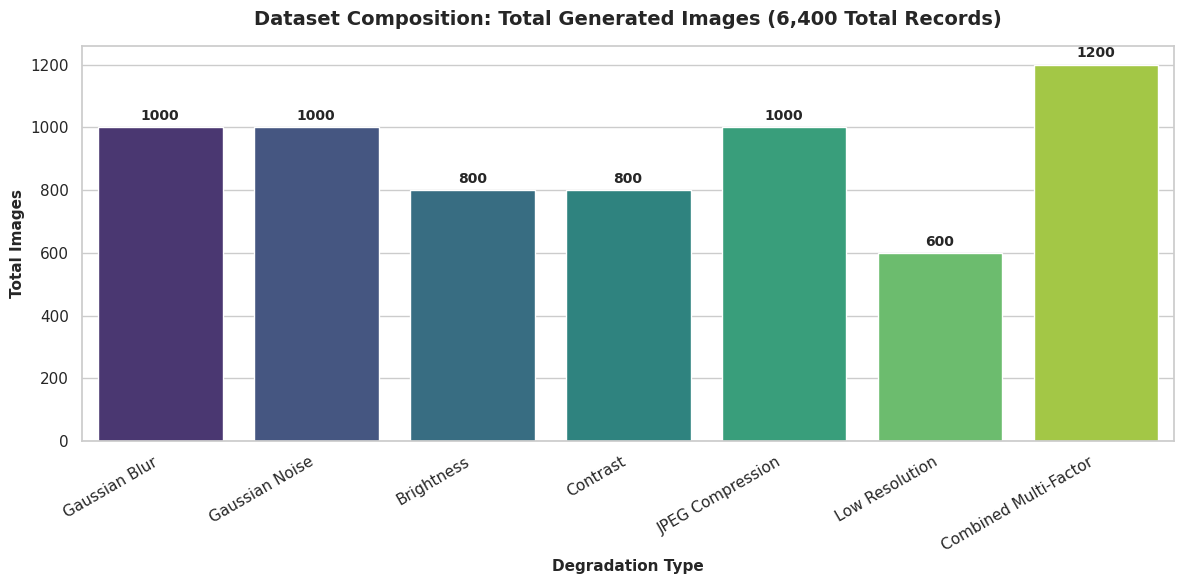

✅ Distribution graph saved locally: 'graphs/degradation_distribution.png'
💾 Distribution graph backed up to Drive: '/content/drive/MyDrive/pre_enhancement_facial_recoverability/graphs/degradation_distribution.png'


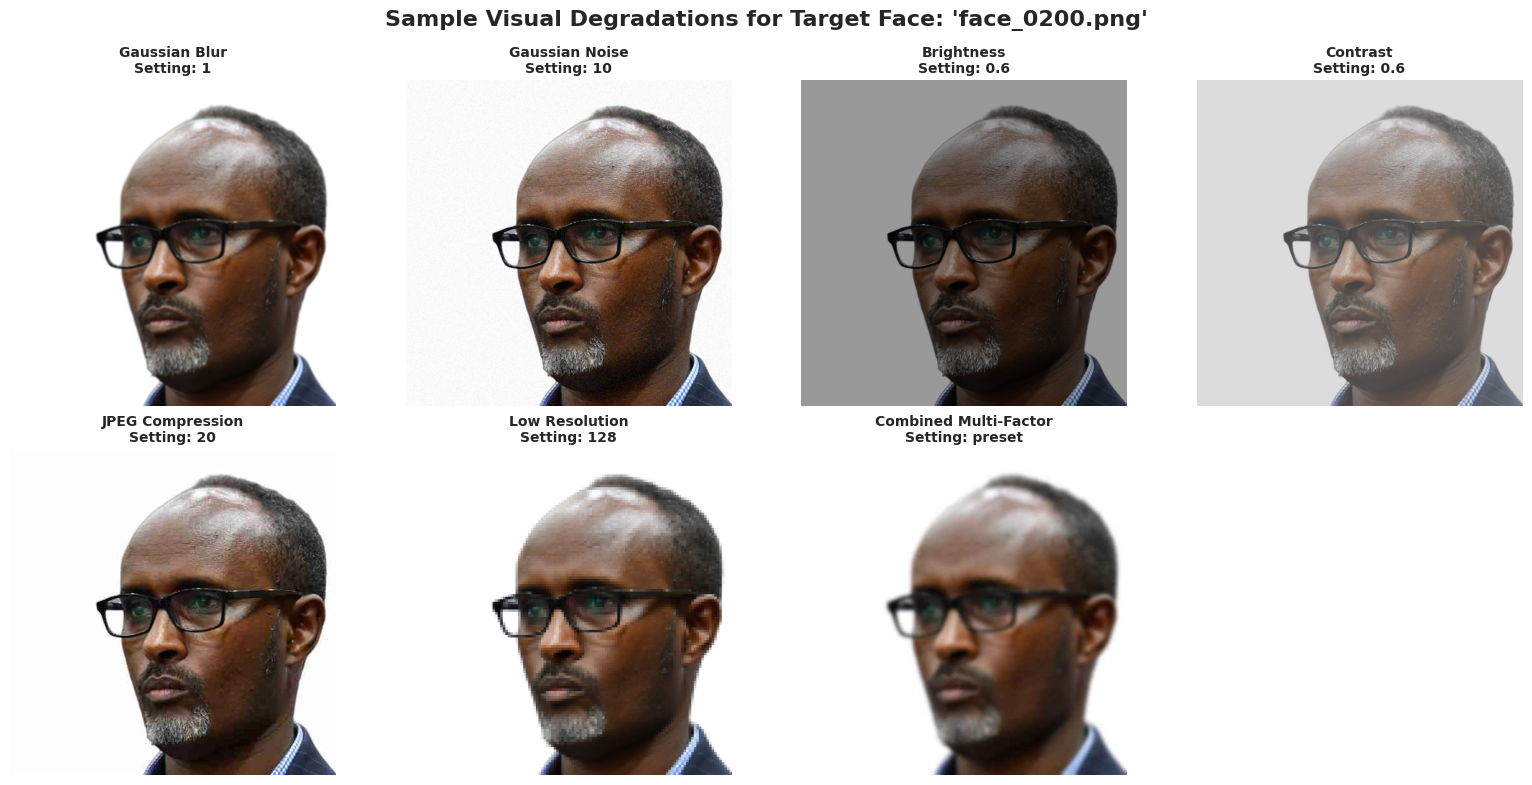

✅ Visual sample comparison grid saved locally: 'graphs/sample_degradations_grid.png'
💾 Visual sample comparison grid backed up to Drive: '/content/drive/MyDrive/pre_enhancement_facial_recoverability/graphs/sample_degradations_grid.png'


In [35]:
# Step: Generate, Display, and Save Dataset Graphs (Saves to both Colab and Google Drive)

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths for local Colab storage and Google Drive backup
LOCAL_GRAPHS_DIR = "graphs"
DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
DRIVE_GRAPHS_DIR = os.path.join(DRIVE_PROJECT, "graphs")

DRIVE_CSV_PATH = os.path.join(DRIVE_PROJECT, "dataset/metadata/metadata.csv")
LOCAL_CSV_PATH = "dataset/metadata/metadata.csv"

# Ensure directories exist locally and on Google Drive
os.makedirs(LOCAL_GRAPHS_DIR, exist_ok=True)
os.makedirs(DRIVE_GRAPHS_DIR, exist_ok=True)

# FORCE RELOAD metadata.csv directly from Drive to load merged batch counts
if os.path.exists(DRIVE_CSV_PATH):
    df = pd.read_csv(DRIVE_CSV_PATH) # <-- CHANGED: Force reloads merged CSV from Google Drive
    print(f"🔄 Reloaded updated dataset from Drive ({len(df):,} total records)")
elif os.path.exists(LOCAL_CSV_PATH):
    df = pd.read_csv(LOCAL_CSV_PATH)
    print(f"🔄 Reloaded dataset from local Colab ({len(df):,} total records)")
else:
    raise FileNotFoundError("Could not find metadata.csv. Please run the Metadata Saver script first.")

# Graph 1: Total Image Count per Degradation Category
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="degradation_type",
    hue="degradation_type",
    palette="viridis",
    legend=False
)
plt.title(f"Dataset Composition: Total Generated Images ({len(df):,} Total Records)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Degradation Type", fontsize=11, fontweight='bold')
plt.ylabel("Total Images", fontsize=11, fontweight='bold')
plt.xticks(rotation=30, ha="right")

# Add numerical values above each bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()

# Save Graph 1 locally and to Google Drive
local_chart_path = os.path.join(LOCAL_GRAPHS_DIR, "degradation_distribution.png")
drive_chart_path = os.path.join(DRIVE_GRAPHS_DIR, "degradation_distribution.png")

plt.savefig(local_chart_path, dpi=300)
plt.savefig(drive_chart_path, dpi=300)
plt.show()  # Renders plot in Colab

print(f"✅ Distribution graph saved locally: '{local_chart_path}'")
print(f"💾 Distribution graph backed up to Drive: '{drive_chart_path}'")

# Graph 2: Visual Comparison Grid of the Latest Target Face
sample_face = df["original_filename"].iloc[-1] # <-- CHANGED: Automatically selects the latest face in the dataset
sample_df = df[df["original_filename"] == sample_face].drop_duplicates(subset=["degradation_type"])

cols = 4
rows = (len(sample_df) + cols - 1) // cols

plt.figure(figsize=(16, 4 * rows))
plt.suptitle(f"Sample Visual Degradations for Target Face: '{sample_face}'", fontsize=16, fontweight='bold', y=0.98)

for idx, (_, row) in enumerate(sample_df.iterrows()):
    img_path = row["drive_path"]
    img = cv2.imread(img_path)

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img_rgb)
        plt.title(f"{row['degradation_type']}\nSetting: {row['parameter_value']}", fontsize=10, fontweight='bold')
        plt.axis("off")

plt.tight_layout()

# Save Graph 2 locally and to Google Drive
local_grid_path = os.path.join(LOCAL_GRAPHS_DIR, "sample_degradations_grid.png")
drive_grid_path = os.path.join(DRIVE_GRAPHS_DIR, "sample_degradations_grid.png")

plt.savefig(local_grid_path, dpi=300)
plt.savefig(drive_grid_path, dpi=300)
plt.show()  # Renders sample grid in Colab

print(f"✅ Visual sample comparison grid saved locally: '{local_grid_path}'")
print(f"💾 Visual sample comparison grid backed up to Drive: '{drive_grid_path}'")

In [36]:
# Check total image counts in Google Drive dataset folders
import os

# Google Drive project path
DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
DIR_ORIGINAL = os.path.join(DRIVE_PROJECT, "dataset/original")
DIR_CROPPED = os.path.join(DRIVE_PROJECT, "dataset/cropped")
DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")

valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')

def count_images(folder_path: str) -> int:
    if not os.path.exists(folder_path):
        return 0
    return len([f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)])

# Get primary counts
orig_count = count_images(DIR_ORIGINAL)
cropped_count = count_images(DIR_CROPPED)
faces_num = cropped_count if cropped_count > 0 else 1

# Metadata structure: (folder_name, display_label, unit_name)
subfolders_info = [
    ("blur", "Blur", "levels"),
    ("noise", "Noise", "levels"),
    ("brightness", "Brightness", "levels"),
    ("contrast", "Contrast", "levels"),
    ("jpeg", "JPEG Compression", "levels"),
    ("low_resolution", "Low Resolution", "levels"),
    ("combined", "Combined Multi-Factor", "presets")
]

degraded_counts = {}
total_degraded = 0

for folder_name, display_label, unit in subfolders_info:
    cnt = count_images(os.path.join(DIR_DEGRADED, folder_name))
    degraded_counts[folder_name] = cnt
    total_degraded += cnt

total_variants_per_face = total_degraded // faces_num
total_combined = orig_count + cropped_count + total_degraded

# Formatted bullet-point output

print("📁 DATASET SUMMARY & STRUCTURE")
print(f"• {orig_count:,} Original Faces (dataset/original/)")
print(f"• {cropped_count:,} Cropped Cutouts (dataset/cropped/)")
print(f"• {total_degraded:,} Degraded Images (dataset/degraded/ across {total_variants_per_face} total variants per face):")

for folder_name, display_label, unit in subfolders_info:
    cnt = degraded_counts[folder_name]
    per_face = cnt // faces_num
    print(f"    - {display_label}: {cnt:,} images ({per_face} {unit} × {faces_num} faces)")

print("\n----------------------------------------------------------------------------")
print(f"📊 Calculation: {orig_count:,} original + {cropped_count:,} cropped + {total_degraded:,} degraded = {total_combined:,} images total.")


📁 DATASET SUMMARY & STRUCTURE
• 1,000 Original Faces (dataset/original/)
• 200 Cropped Cutouts (dataset/cropped/)
• 6,400 Degraded Images (dataset/degraded/ across 32 total variants per face):
    - Blur: 1,000 images (5 levels × 200 faces)
    - Noise: 1,000 images (5 levels × 200 faces)
    - Brightness: 800 images (4 levels × 200 faces)
    - Contrast: 800 images (4 levels × 200 faces)
    - JPEG Compression: 1,000 images (5 levels × 200 faces)
    - Low Resolution: 600 images (3 levels × 200 faces)
    - Combined Multi-Factor: 1,200 images (6 presets × 200 faces)

----------------------------------------------------------------------------
📊 Calculation: 1,000 original + 200 cropped + 6,400 degraded = 7,600 images total.
